# Module 3: Content Understanding & Semantic Chunking

In **Module 2**, we solved the "Invisibility" problem: we found the bounding boxes of tables and figures.

But finding a figure isn't enough. A RAG system needs to **understand** what's inside it.
- **Module 1 (Naive)**: Ignored figures completely.
- **Module 2 (Layout)**: Found the box `[x, y, w, h]`.
- **Module 3 (Content Understanding)**: describing the figure using Multimodal AI (GPT-4o) and using document structure for **Semantic Chunking**.

## Objectives
1. **Multimodal Analysis**: Use GPT-4o to generate a text description of the Circuit Diagram (Page 12).
2. **Semantic Chunking**: Group text by *Section Headers* instead of arbitrary character counts.

In [4]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path("../../src").resolve()))

from utils import load_env
import pandas as pd
from IPython.display import Image, display, Markdown
import base64

from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from openai import AzureOpenAI
from azure.ai.documentintelligence import DocumentIntelligenceClient

# Load environment variables
env = load_env()

# --- 1. Setup Document Intelligence (for Structure) ---
doc_endpoint = env["AZURE_DOCUMENT_INTELLIGENCE_ENDPOINT"]
credential = DefaultAzureCredential()
doc_client = DocumentIntelligenceClient(endpoint=doc_endpoint, credential=credential)

# --- 2. Setup OpenAI GPT-4o (for Understanding) ---
token_provider = get_bearer_token_provider(credential, "https://cognitiveservices.azure.com/.default")

aoai_client = AzureOpenAI(
    azure_endpoint=env["AZURE_OPENAI_ENDPOINT"],
    azure_ad_token_provider=token_provider,
    api_version="2024-08-01-preview"
)

deployment_name = env.get("AZURE_OPENAI_DEPLOYMENT_GPT4o", "gpt-4o") # fallback to gpt-4o if not set

print("Clients Initialized (Doc Intel + OpenAI).")

Clients Initialized (Doc Intel + OpenAI).


## Lab 3.1: Multimodal Figure Understanding

In Module 2, we detected a Figure on Page 12. Now, let's ask GPT-4o to explain it.
We will simluate "cropping" the figure by loading the `page12.png` image (which represents the page content).

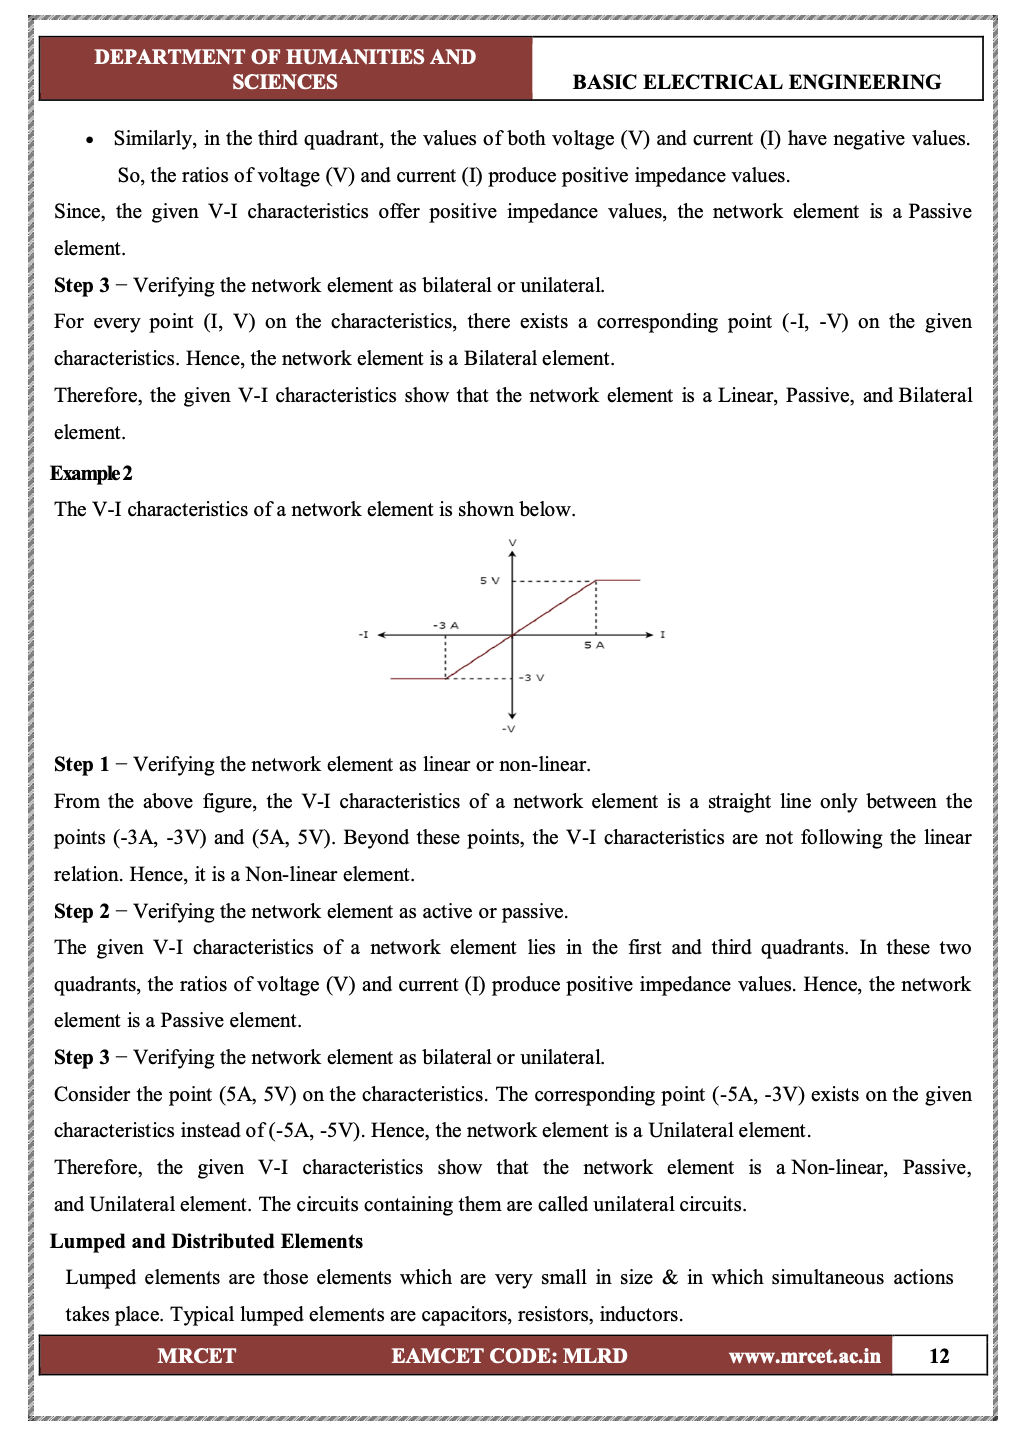

Sending image to GPT-4o for analysis...

--- GPT-4o Analysis ---
The provided diagram and the associated text analyze the V-I characteristics of a network element specifically described in Example 2. Let's summarize the findings based on the details given:

### Circuit Topology and Components:

The V-I characteristics plotted in the graph show the relationship between voltage (V) and current (I) for a particular network element. This graph does not directly specify the physical components or their connections in a circuit but provides crucial information about the behavior of the network element.

### Extracted Characteristics and Equations:

1. **Linear vs. Non-linear Element**:
   - The characteristic is linear between the points (-3A, -3V) and (5A, 5V). However, beyond these points, the relationship does not follow a linear behavior. Therefore, the network element is classified as a Non-linear element.

2. **Active vs. Passive Element**:
   - The V-I characteristics lie in the first

In [ ]:
# Path to the image
IMG_PATH = Path("../module-1-naive-rag/page12.png")

if IMG_PATH.exists():
    display(Image(filename=IMG_PATH, width=500))
else:
    print(f"⚠️ Image not found at {IMG_PATH}")

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

base64_image = encode_image(IMG_PATH)

# GENERIC PROMPT - More realistic for automated pipelines
# We don't know it's a circuit, or a chart, or a photo.
system_prompt = "You are a helpful assistant that analyzes images from technical documents."
user_prompt = "Describe this image in detail. If it contains text or equations, transcribe them. If it is a diagram, explain its structure and meaning."

print(f"Sending image to GPT-4o with GENERIC prompt:\n'{user_prompt}'\n...")

response = aoai_client.chat.completions.create(
    model=deployment_name,
    messages=[
        {"role": "system", "content": system_prompt}, 
        {"role": "user", "content": [
            {"type": "text", "text": user_prompt},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{base64_image}"}}
        ]}
    ],
    max_tokens=500
)

description = response.choices[0].message.content
print("\n--- GPT-4o Analysis (Generic) ---")
print(description)

print("\n✅ SUCCESS: Even with a generic prompt, GPT-4o figures out it's a V-I characteristic graph.")

## Lab 3.2: Semantic Chunking

Now let's look at text. In Module 1, we chopped text every 500 characters.
Here, we will use the **Document Map** from Document Intelligence to chunk by **Section Headers**.

This ensures that a whole topic stays together.

In [5]:
DATA_DIR = Path("../../data/sample-pdfs")
PDF_PATH = DATA_DIR / "Basic Electrical Engineering R-20.pdf"

print(f"Analyzing {PDF_PATH} (Layout Model)...")
# Re-run analysis for this module to be self-contained
with open(PDF_PATH, "rb") as f:
    poller = doc_client.begin_analyze_document("prebuilt-layout", f)
    result = poller.result()

print("Analysis complete.")

Analyzing ../../data/sample-pdfs/Basic Electrical Engineering R-20.pdf (Layout Model)...
Analysis complete.


In [6]:
# --- SEMANTIC CHUNKING LOGIC ---
# Strategy: 
# 1. Iterate through paragraphs.
# 2. If we hit a 'sectionHeading', start a new chunk.
# 3. Accumulate content until the next heading.

semantic_chunks = []
current_chunk = {"title": "Intro", "content": ""}

for p in result.paragraphs:
    role = p.role if p.role else "body"
    content = p.content
    
    if role == "sectionHeading":
        # Save previous chunk if it has content
        if current_chunk["content"].strip():
            semantic_chunks.append(current_chunk)
        
        # Start new chunk
        current_chunk = {"title": content, "content": ""}
    else:
        # Append to current chunk
        # Filter out page headers/footers here if desired (as learned in Mod 2)
        if role not in ["pageHeader", "pageFooter"]:
            current_chunk["content"] += content + "\n"

# Add last chunk
if current_chunk["content"].strip():
    semantic_chunks.append(current_chunk)

print(f"Created {len(semantic_chunks)} Semantic Chunks.")

# Inspect a few
for i, chunk in enumerate(semantic_chunks[:3]):
    print(f"--- Chunk {i+1}: {chunk['title']} ---")
    print(chunk['content'][:200].replace("\n", " ") + "...")
    print("-----------------------------------\n")

Created 158 Semantic Chunks.
--- Chunk 1: Intro ---
BASIC ELECTRICAL ENGINEERING DIGITAL NOTES LIVE TO LEARN & LEARN TO SHARE MALLA REDDY COLLEGE OF ENGINEERING & TECHNOLOGY (Autonomous Institution - UGC, Govt. of India) Recognized under 2(f) and 12 (B...
-----------------------------------

--- Chunk 2: Objectives: ---
1. To understand the basic concepts of electrical circuits & networks and their analysis which is the foundation for all the subjects in the electrical engineering discipline. 2. To emphasize on the b...
-----------------------------------

--- Chunk 3: TEXT BOOKS: ---
1. Engineering Circuit Analysis - William Hayt, Jack E. Kemmerly, S M Durbin, Mc Graw Hill Companies. 2. Electric Circuits - A. Chakraborty, Dhanipat Rai & Sons. 3. Electrical Machines - P.S. Bimbra, ...
-----------------------------------



## Conclusion

We have upgraded our pipeline:
1. **Figures**: Are no longer invisible holes; they are text descriptions generated by GPT-4o.
2. **Text**: Is no longer arbitrary fragments; it is organized by **Topic** (Headings).

In **Module 6 (Retrieval)**, we will see how these improvements lead to vastly better search results.

In [7]:
# --- 3. COMPARISON: FIXED VS SEMANTIC ---
print("\n--- 🔍 COMPARISON: Module 1 (Fixed) vs Module 3 (Semantic) ---")

# Let's take the "Objectives" section as an example
# In Semantic chunking, we captured it cleanly as "Chunk 2" above.
semantic_example = next((c for c in semantic_chunks if "Objective" in c['title']), None)

print(">>> [SEMANTIC CHUNK]:")
if semantic_example:
    print(f"Title: {semantic_example['title']}")
    print(f"Content Length: {len(semantic_example['content'])} chars")
    print(f"Start: '{semantic_example['content'][:50]}...'")
    print(f"End:   '...{semantic_example['content'][-50:]}'")
    print("\n✅ RESULT: The entire 'Objectives' list (1, 2, 3...) is kept together.")
else:
    print("Objectives chunk not found.")

print("\n>>> [NAIVE CHUNK SIMULATION (500 chars)]:")
# Let's simulate what happens if we cut that same text at 500 chars randomly
if semantic_example:
    text = semantic_example['content']
    # Imagine the naive chunk started 50 chars before this section and cut off at 500
    simulated_naive_chunk = text[100:600] 
    print(f"Start: '...{simulated_naive_chunk[:50]}...'")
    print(f"End:   '...{simulated_naive_chunk[-50:]}...'")
    print("\n❌ RESULT: It likely starts in the middle of a sentence and cuts off point #3.")
    print("   If you search for 'What is objective #4?', the Naive chunk might miss it completely.")


--- 🔍 COMPARISON: Module 1 (Fixed) vs Module 3 (Semantic) ---
>>> [SEMANTIC CHUNK]:
Title: Objectives:
Content Length: 1843 chars
Start: '1. To understand the basic concepts of electrical ...'
End:   '...ations for energy consumption and battery backup.
'

✅ RESULT: The entire 'Objectives' list (1, 2, 3...) is kept together.

>>> [NAIVE CHUNK SIMULATION (500 chars)]:
Start: '...e foundation for all the subjects in the electrica...'
End:   '...rk, Types of elements, R-L-C Parameters, Independe...'

❌ RESULT: It likely starts in the middle of a sentence and cuts off point #3.
   If you search for 'What is objective #4?', the Naive chunk might miss it completely.
